# Advanced Lane Finding

This Jupyter notebook contains an application to find lane lines in a video captured from a dashcam while driving
on a highway.  The application is intended to satisfy the requirements for the Advanced Lane Finding project in
the Udacity Nanodegree on Self-Driving Car Engineering.

## Sample Inputs and Outputs

Here are examples of an input frame and the resulting output frame with the driving lane highlighted in green.

[//]: # (Image References)

<figure>
 <img src="test_images/straight_lines1.jpg" width="380" alt="Combined Image" />
 <figcaption>
 <p></p> 
 <p style="text-align: center;"> Here is an example of an input frame from a video. </p> 
 </figcaption>
</figure>
 <p></p> 
<figure>
 <img src="examples/example_output.jpg" width="380" alt="Combined Image" />
 <figcaption>
 <p></p> 
 <p style="text-align: center;"> The output should look something like this (above) after detecting
     left and right lane lines.</p> 
 </figcaption>
</figure>

# Imports
Here are the imported library objects required to support this application.

In [1]:
#importing some useful packages
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
import os
import glob
from itertools import chain
from math import copysign
print()

# Helper Function Constants

In [2]:
#CHESS BOARD
CHESS_BOARD_ROWS = 9
CHESS_BOARD_COLS = 6

#Hough
HOUGH_RHO = 2
HOUGH_THETA = np.pi/(1*180)
HOUGH_THRESHOLD = 15
HOUGH_MIN_LEN = 35 #25
HOUGH_MAX_GAP = 35

#Pixel threshold activation
THRESHOLD_GAMMA = 3.0

#Conversion from pixels to meters
## Highway guidelines recommend a minimum of 3.6m lane width
## Highway guidelines recommend lane stripes of 3m and gaps of 9m
YM_PER_PIX = 30/720 # meters per pixel in y dimension
XM_PER_PIX = 3.7/700 # meters per pixel in x dimension

#Search margin around a prior polynomial
POLY_SEARCH_MARGIN = 100

#class Line
MAX_XFITTED_LEN = 15
MAX_RECENT_DETECTION_LEN = 15
MAX_HIST_LEN = 15

# Helper Functions
Here are the helper functions required by the application.

In [3]:
def weighted_img(img, initial_img, α=0.8, β=1., γ=0.):
    """
    `img` is a blank image (all black) with lines or other figures drawn on it.
    
    `initial_img` is an image onto which img will be composited.
    
    The resulting image is computed as follows:
    
    initial_img * α + img * β + γ
    NOTE: initial_img and img must be the same shape!
    """
    return cv2.addWeighted(initial_img, α, img, β, γ)

def draw_lines(img, lines, color=[255, 0, 0], thickness=2):
    """
    This function draws `lines` with `color` and `thickness`.    
    Lines are drawn on the image inplace (mutates the image).
    If you want to make the lines semi-transparent, think about combining
    this function with the weighted_img() function below
    """
    for line in lines:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), color, thickness)

def draw_circles(img, centers, radii, colors, thickness=3):
    for i in range(len(centers)):
        #print("draw_circles: centers: ", centers, " radii: ", radii, " colors: ", colors)
        cv2.circle(img, centers[i], radii[i], colors[i], thickness=thickness)


## TODO: Some new facilities are needed or desired to keep the architecture pliable.
## 1) Hide the details about an image's origin and storage.  Functions which operate on image data
##    should not have to mess with file or network I/O, nor should they be allowed to know
##    what was or will be done with the image in prior and subsequent steps.
## 2) Hide details about the output of figures.  Image manipulation functions should not know
##    how or whether the objects it operates on will be written to any type of display.  This
##    requirement is similar to 1) above -- decouple processing from I/O.

def display_images(images, titles=[], shape=(0,0), figuresize=None, figuretitle=None):
    """
    Display a list of images and corresponding titles
    """
    col_width = 3
    
    if shape == (0,0):
        shape = (1 + len(images)//col_width, min(len(images), col_width))
    elif shape[0] == -1:
        shape = (len(images)//shape[1], shape[1])
    #print("shape: ", shape)
    
    title_deficiency = len(images) - len(titles)
    if title_deficiency > 0:
        titles.extend([None] * title_deficiency)
        
    fig = plt.figure(frameon=True)
    fig.tight_layout()
    fig.set_figheight(figuresize[0] if figuresize != None else 15)
    fig.set_figwidth(figuresize[1] if figuresize != None else 15)
    if figuretitle != None:
        fig.suptitle(figuretitle, fontsize=16)
    
    for row in range(shape[0]):
        for col in range(shape[1]):
            if len(images) >= row * shape[1] + col + 1:
                a = fig.add_subplot(shape[0], shape[1], row * shape[1] + col + 1)
                a.set_title(titles[row * shape[1] + col])
                a.axis('off')
                a.set_xticks([])
                a.set_yticks([])
                img = images[row * shape[1] + col]
                color_map = 'gray' if (len(img.shape) <= 2) or (img.shape[2] <= 1) else None
                a.imshow(images[row * shape[1] + col], cmap=color_map)

def hls(img):
    img = np.copy(img)
    # Convert RGB to HLS color space and return the Hue, Lightness and Saturation channels
    hls = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)
    return hls[:,:,0], hls[:,:,1], hls[:,:,2]
    
def hsv(img):
    img = np.copy(img)
    # Convert RGB to HSV color space and return the H, S and V channels
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    return hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

def make_list_pairs(a, b):
    """
    Given lists a and b, return coordinate pairs [[a[0], b[0]], [a[1], b[1]], ... [a[n], b[n]]]
    """
    return np.reshape(np.array(list(chain(*zip(a,b)))), (-1,2))

def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """  
    Returns a list of found lines, and an image with those lines drawn.
    """
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]),
                            minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    draw_lines(line_img, lines)
    return  lines, line_img

## 3) Logging facility for debugging.  Hopefully find an existing class.
## 4) Cacheing of intermediate artifacts, such as intermediate images, arrays, lists, etc. so they
##    can be accessed from other parts of the program without necessarily requiring that the
##    call tree be explicitly modified to pass them around.  Again, look for an existing library.
##    This can be valuable for making rapid changes for demonstration purposes, such as
##    when a last minute decision is made to add additional details to a plot.
## 5) A design which treats the pipeline itself as a container or network, allowing individual steps to be
##    inserted, removed or reordered on the fly.  This will require a reliable way of specifying
##    producers and consumers of specific data objects.  It will also require detailed thought
##    regarding function argument defaults and how reasonable arguments can be deduced depending
##    on the environment and the nature of the function's primary inputs.  While a full architecture
##    of this nature may be beyond the scope of this project, it is worth pondering because a
##    mutable network of operations would support multi-processing and hot reconfiguration
##    of the pipeline depending on detected conditions.  For example, a step for reacquiring lane
##    line from scratch could be inserted only when other pipeline steps determine that the
##    location of the lane lines are no longer known with certainty.  It would also support
##    experiments in which a control system manipulates the pipeline to search for an optimal
##    operating configuration.

# Line Class
This class holds useful details about the history of a line or curve, as in a left or right lane line.

In [67]:
class Line():
    
    COEFF_EPSILON_SAME_SIGN = 1.0e-03
    COEFF_EPSILON_OPP_SIGN = 1.0e-05
    
    def __init__(self):
        # history of the success (True) or failure (False) of recent detections
        self.__recent_detections = []  
        # x values of the last n fits of the line
        #self.__recent_xfitted = [np.array([], dtype=np.int, ndmin=2)]
        self.__xfitted_history = []
        #average x values of the fitted line over the last n iterations
        self.__bestx = None
        self.__coeff_history = [np.array([], dtype=np.float64, ndmin=2)]
        #polynomial coefficients averaged over the last n iterations
        self.__best_fit = [np.array([], dtype=np.float64, ndmin=1)]  
        #polynomial coefficients for the most recent fit
        self.__current_fit = [np.array([False])]  
        #radius of curvature of the line in some units
        self.__radius_of_curvature = None 
        #distance in meters of vehicle center from the line
        self.__line_base_pos = None 
        #difference in fit coefficients between last and new fits
        self.__diffs = np.array([0,0,0], dtype='float') 
        #x values for detected line pixels
        self.__allx = None  
        #y values for detected line pixels
        self.__ally = None  
        
    def detected(self):
        return self.__recent_detections[-1]
    
    def add_detected(self, val):
        self.recent_detections(np.array(val))
        
    def detection_rate(self):
        rd = self.recent_detections()
        return len(np.nonzero(rd))/len(rd)
        
    def recent_detections(self):
        return self.__recent_detections
    
    def add_detection(self, val):
        self.__recent_detections.append(val)
        if len(self.__recent_detections) > MAX_RECENT_DETECTION_LEN:
            self.__recent_detections.pop(0)
    
    def last_xfitted(self):
        return self.__xfitted_history[-1]
               
    def xfitted_history(self):
        return self.__xfitted_history
    
    def add_xfitted(self, val):
        a = np.array(val)
        print(a)
        self.__xfitted_history.append(a)
        if len(self.__xfitted_history) > MAX_HIST_LEN:
            self.__xfitted_history.pop(0)
            
    def average_xfitted(self, n=MAX_XFITTED_LEN, useOnlyDetected=True):
        n = min(n, MAX_XFITTED_LEN)
        if useOnlyDetected == True:
            n = min(n, MAX_RECENT_DETECTION_LEN)
            avg = np.average(self.xfitted_history()[np.nonzero(self.recent_detections()[:n])], axis=0)
        """
        count = 0
        total = 0
        for i in range(n):
            if self.recent_detections[-1-i] == True:
                total += self.__xfitted_history[-1-i]
                count += 1
                
        if count > 0:
            avg = total / count
        else:
            avg = 0
        """
        return avg
            
    def bestx(self):
        return self.__bestx
    
    def add_bestx(self, val):
        self.__bestx = np.array(val, dtype=np.int, ndmin=1)
        
    def coeff_history(self):
        return self.__coeff_history
    
    def push_coeff(self, val):
        self.__coeff_history.append(val)
        if len(self.__coeff_history) > MAX_HIST_LEN:
            self.__coeff_history.pop(0)
            
    def coeff_same_sign(self, line):
        return int(copysign(1., self.last_fit()[0])) == int(copysign(1., line.last_fit()[0]))
        
    def coeff_diff(self, line):
        if self.coeff_same_sign(line) == True:
            d = self.last_fit()[0] - line.last_fit()[0]
        else:
            d = abs(self.last_fit()[0]) - abs(line.last_fit()[0])
        return d
    
    def coeff_change(self, this=-1, back=1):
        """
        Difference between two sets of coefficients.  The default for "this"
        is -1 which is the index of the most recently saved coefficients.
        "back" is the number of entries prior to "this".
        """
        i = this if this >= 0 else this + len(self.__coeff_history)
        i = i if i < len(self.__coeff_history) else len(self.__coeff_history) - 1
        h = self.__coeff_history    
        if 0 < back < i:
            cc = [h[i][a] - h[i-back][a] for a in range(len(h[i]))]
        else:
            cc = [0. for a in range(len(h[i]))]
        return cc
    
    def coeff_compatible(self, line):
        if self.coeff_same_sign(line) == True:
            r = abs(self.coeff_diff(line)) < Line.COEFF_EPSILON_SAME_SIGN
        else:
            r = abs(self.coeff_diff(line)) < Line.COEFF_EPSILON_OPP_SIGN
            
        return r
            
    def best_fit(self):
        return self.__best_fit
    
    def add_best_fit(self, val):
        self.__best_fit = val
        
    def last_fit(self):
        return self.coeff_history()[-1]
        
    def radius_of_curvature(self):
        return self.__radius_of_curvature
    
    def set_radius_of_curvature(self, val):
        self.__radius_of_curvature = val
        
    def line_base_pos(self):
        return self.__line_base_pos
    
    def set_line_base_pos(self, val):
        self.__line_base_pos = val
        
    def diffs(self):
        return self.__diffs
    
    def set_diffs(self, val):
        self.__diffs = val
        
    def allx(self):
        return self.__allx
    
    def set_allx(self, val):
        self.__allx = val
    
    def ally(self):
        return self.__ally
    
    def set_ally(self, val):
        self.__ally = val

In [68]:
x = np.ndarray(shape=(3,4))
mask = np.array([1,0,1])
x[0] = [1,2,3,4]
x[1] = [2,2,5,7]
x[2] = [3,2,10,12]
#a = x[0] + x[1] + x[2]
a = np.sum(x, axis=0)
print(a/3)
a = np.average(x, axis=0)
print(a)
a = np.average(x[np.nonzero(mask)], axis=0)
print(a)

[ 2.          2.          6.          7.66666667]
[ 2.          2.          6.          7.66666667]
[ 2.   2.   6.5  8. ]


In [69]:
coeff = [[0.1e-01, -0.002, 300.],
         [0.1e-01 + Line.COEFF_EPSILON_SAME_SIGN, -0.002, 300.],
         [0.1e-01 + 2 * Line.COEFF_EPSILON_SAME_SIGN, -0.003, 300.],
         [-0.1e-01 - Line.COEFF_EPSILON_OPP_SIGN, -0.003, 400.],
         [-0.1e-01 - 2 * Line.COEFF_EPSILON_OPP_SIGN, -0.004, 600.]
        ]

line1 = Line()
line2 = Line()
line3 = Line()

line1.set_radius_of_curvature(1265.34)
print(line1.radius_of_curvature() == 1265.34)
bx = [1,2,3,4,5]
line1.add_bestx(bx)
print(line1.bestx() == bx)
print('COEFF_EPSILON_SAME_SIGN: ', Line.COEFF_EPSILON_SAME_SIGN, 'COEFF_EPSILON_OPP_SIGN: ', Line.COEFF_EPSILON_OPP_SIGN)
pos_line, neg_line = Line(), Line()
pos_line.push_coeff([1.,0.,0.])
neg_line.push_coeff([-1.,0.,0.])
print('[1.,0.,0,] same sign as [-1.,0.,0.]: ', pos_line.coeff_same_sign(neg_line))
print('[1.,0.,0,] same sign as [1.,0.,0.]: ', pos_line.coeff_same_sign(pos_line))
print('[-1.,0.,0,] same sign as [-1.,0.,0.]: ', neg_line.coeff_same_sign(neg_line))
print('[-1.,0.,0,] same sign as [1.,0.,0.]: ', neg_line.coeff_same_sign(pos_line))
print('copysign(3,-1) = ', copysign(3,-1))
line1.push_coeff(coeff[0])
print('line1 push:', line1.coeff_history()[-1])
print(line1.last_fit == coeff[0])
line2.push_coeff(coeff[1])
print('line2 push:', line2.coeff_history()[-1])
print('Diff: ', line1.coeff_diff(line2), 'Compatible? ', line1.coeff_compatible(line2))
line2.push_coeff(coeff[2])
print('line2 push:', line2.coeff_history()[-1])
print('Diff: ', line1.coeff_diff(line2), 'Compatible? ', line1.coeff_compatible(line2))
print('Change from prior: ', line2.coeff_change())
line2.push_coeff(coeff[3])
print('line2 push:', line2.coeff_history()[-1])
print('Diff: ', line1.coeff_diff(line2), 'Compatible? ', line1.coeff_compatible(line2))
print('Change from prior: ', line2.coeff_change())
line2.push_coeff(coeff[4])
print('line2 push:', line2.coeff_history()[-1])
print('Diff: ', line1.coeff_diff(line2), 'Compatible? ', line1.coeff_compatible(line2))
print('line2 change from prior: ', line2.coeff_change())
print('line2 change from 2 prior: ', line2.coeff_change(back=2))
line3.add_xfitted([1,2,3,4,5,6])
line3.add_detection(True)
line3.add_xfitted([2,2,5,7,9,11])
line3.add_detection(True)
line3.add_xfitted([4,2,8,10,10,15])
line3.add_detection(True)
line3.add_xfitted([500,200,900,1100,1100,1600])
line3.add_detection(False)
line3.add_xfitted([4,2,8,10,10,15])
line3.add_detection(True)
print(line3.average_xfitted())
print(line3.average_xfitted(useOnlyDetected=False))


True
[ True  True  True  True  True]
COEFF_EPSILON_SAME_SIGN:  0.001 COEFF_EPSILON_OPP_SIGN:  1e-05
[1.,0.,0,] same sign as [-1.,0.,0.]:  False
[1.,0.,0,] same sign as [1.,0.,0.]:  True
[-1.,0.,0,] same sign as [-1.,0.,0.]:  True
[-1.,0.,0,] same sign as [1.,0.,0.]:  False
copysign(3,-1) =  -3.0
line1 push: [0.01, -0.002, 300.0]
False
line2 push: [0.011, -0.002, 300.0]
Diff:  -0.0009999999999999992 Compatible?  True
line2 push: [0.012, -0.003, 300.0]
Diff:  -0.002 Compatible?  False
Change from prior:  [0.0010000000000000009, -0.001, 0.0]
line2 push: [-0.01001, -0.003, 400.0]
Diff:  -9.999999999999593e-06 Compatible?  True
Change from prior:  [-0.022010000000000002, 0.0, 100.0]
line2 push: [-0.01002, -0.004, 600.0]
Diff:  -1.9999999999999185e-05 Compatible?  False
line2 change from prior:  [-9.999999999999593e-06, -0.001, 200.0]
line2 change from 2 prior:  [-0.022019999999999998, -0.001, 300.0]
[1 2 3 4 5 6]
[ 2  2  5  7  9 11]
[ 4  2  8 10 10 15]
[ 500  200  900 1100 1100 1600]
[ 4  2

TypeError: list indices must be integers or slices, not tuple

# Test Images

In [ ]:
# Read in and make a list of lane images
file_names = glob.glob('./test_images/*.jpg')

file_names = sorted(file_names)
test_images = []
test_image_file_names = []

for fname in file_names:
    test_images.append(mpimg.imread(fname))
    test_image_file_names.append(fname)

In [ ]:
cols = 4
rows = len(test_images)//cols
display_images(test_images, test_image_file_names, shape=(rows,cols), figuresize=(6,16), figuretitle='Test Images')

# Functions for Individual Pipeline Steps

## Camera Calibration
These functions support the creation of a camera calibartion matrix and distortion coefficinets 
which are used to correct camera images so they more closely reflect real world values.  Without
the camera correction matrix and distorion coefficients, calculations based on captured camera
images would lead to innaccurate location values, and uptimately to incorrect steering instructions
for the vehicle.

In [ ]:
# Read in and make a list of calibration images
images = glob.glob('./camera_cal/calibration*.jpg')

objpoints = [] #3D points in realworld space
imgpoints = [] #2D points in image plane
originals = [] #images for illustration
captions = [] #captions for illustration
chess_dims = (CHESS_BOARD_ROWS, CHESS_BOARD_COLS)

#Prepare object points
objp = np.zeros((CHESS_BOARD_COLS*CHESS_BOARD_ROWS, 3), np.float32)
objp[:,:2] = np.mgrid[0:chess_dims[0],0:chess_dims[1]].T.reshape(-1,2) #x,y coordinates

for fname in images:
    # Read in each image
    img = mpimg.imread(fname)
    
    # Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, chess_dims, None)

    # If corners are found, add object points and image points
    if ret == True:
        imgpoints.append(corners)
        objpoints.append(objp)
        
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, chess_dims, corners, ret)
        ## TODO: Save the image with a logging call so it can be
        ## accessed in other contexts.
        originals.append(img)
        captions.append('Original-'+fname)
        captions.append('Undistorted-'+fname)
        
# Calibrate the camera
ret, mtx, dist, rvec, tvec = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

# Create a list of undistorted images
undst = [cv2.undistort(img, mtx, dist, None, mtx) for img in originals]
chessboard_images = list(chain(*zip(originals, undst)))

## See all of the images
#display_images(chessboard_images, captions, shape=(len(originals),2), figuresize=(3*len(originals),14))

## OR, just look at the first several images
nToLookAt = 8
display_images(chessboard_images[:nToLookAt], captions[:nToLookAt], shape=(nToLookAt,2), figuresize=(3*nToLookAt,14))

chessboard_images = None

## Apply Distortion Correction to Raw Images
These functions apply the distortion coefficients calculated during camera calibration to be used to correct each new camera frame.  Close inspection of the corrected image reveals that points near the periphery of
the image have been shifted outward from the center in both the x and y directions in proportion to their distance from the center.  The two red dots in the images below are located at the same coordinates in each respective image.  Objects at those locations have clearly shifted radially.

In [ ]:
img = mpimg.imread("./test_images/straight_lines1.jpg")
sample_pts = [(237, 688), (1195, 448)]
img_copy = img.copy()
dst = cv2.undistort(img_copy, mtx, dist, None, mtx)
draw_circles(img, sample_pts, [6,6], [(255,0,0),(255,0,0)])
draw_circles(dst, sample_pts, [6,6], [(255,0,0),(255,0,0)])
display_images([img, dst], ['Original', 'Distortion Corrected'], figuresize=(4,14))

## Perspective Transform
Apply a perspective transform to rectify the binary image.  This produces a "birds-eye view" of the scene instead
of the view as seen by a driver from behind the steering wheel.  Such a view is useful because accurate measurements
can be pulled directly from such a transformed image just as if it were a local map of the road section located
directly in from of the car.

Note the circles in the images below.  Their distortion in the transformed image emphasize the extent to which the farthest points in the original image have been dispersed.

In [ ]:
img = mpimg.imread("./test_images/straight_lines1.jpg")

# Four source coordinates should be vertically symmetric.  If instead they are aligned with
# lane markers they may not accurately reflect lane curvature.
# The center of the x axis is...
x_center = img.shape[1]//2 + 10
print(x_center)

lane_perspective_markers = np.float32(
    [[723, 475], #top right
    [1035, 670], #bottom right
    [275, 670],  #bottom left
    [567, 470]]) #top left

# Calculate the apparent widths of the lane near the bottom of the image and farther away
bot_lane_w = lane_perspective_markers[1,0] - lane_perspective_markers[2,0]
top_lane_w = lane_perspective_markers[0,0] - lane_perspective_markers[3,0]

# points should have x-coordinates which are vertically symmetric about x_center
"""
src = np.float32(
    [[x_center + top_lane_w//2, lane_perspective_markers[0,1]], #top right
    [x_center + bot_lane_w//2, lane_perspective_markers[1,1]], #bottom right
    [x_center - bot_lane_w//2, lane_perspective_markers[1,1]],  #bottom left
    [x_center - top_lane_w//2, lane_perspective_markers[0,1]]]) #top left
"""
src = lane_perspective_markers

left_x, right_x = 320, 1000
top_y, bottom_y = 150, 640

dst = np.float32(
    [[right_x, top_y],
    [right_x, bottom_y],
    [left_x, bottom_y],
    [left_x, top_y]])

# Define perspective transform function
## TODO: wrap this function into a class ImageWarp which computes M and Minv only once,
##       then uses them in member functions warp and unwarp.
def warp(img, src, dst):
    
    # Define calibration box in source (original) and destination (desired or warped) coordinates
    img_size = (img.shape[1], img.shape[0])

    # Compute the perspective transform
    M = cv2.getPerspectiveTransform(src, dst)
    
    # Compute the inverse by swapping the inputs
    Minv = cv2.getPerspectiveTransform(dst, src)
    
    # Create warped image -- uses linear interpolation
    warped = cv2.warpPerspective(img, M, img_size, flags=cv2.INTER_LINEAR)
    
    return warped, M, Minv

marked_img = img.copy()

#mark the image with reference circles
#centers = [(int(c[0]), int(c[1])) for c in src]
centers = [(int(c[0]), int(c[1])) for c in lane_perspective_markers]
colors = [(0,0,255), (0,255,0), (255,0,0), (255,255,0)] #blue, green, red, yellow
radii = [10] * len(centers)
draw_circles(marked_img, centers, radii, colors, thickness=6)

# Get perspective transform
warped_marked_im, M, Minv = warp(marked_img, src=src, dst=dst)
warped_im, _, _ = warp(img, src=src, dst=dst)

# Transform back to original perspective
restored_im, _, _ = warp(warped_marked_im, src=dst, dst=src)

images = [marked_img, warped_marked_im, restored_im, warped_im]
captions = ['Source Image with Markers', 'Warped Image with Markers', 'Restored Image', 'Warped Image']
figuretitle = 'Creating a Birds-eye View of the Lane'
display_images(images, captions, shape=(2,2), figuresize=(8,14), figuretitle=figuretitle)

## Create Warped Images of Test Images

In [ ]:
for i in test_images:
    undist_imgs = [cv2.undistort(img, mtx, dist, None, mtx) for img in test_images]
    warped_undist = [warp(undist, src=src, dst=dst)[0] for undist in undist_imgs] #lens corrected
    warped_orig = [warp(img, src=src, dst=dst)[0] for img in test_images] #not lens corrected
    
cols = 4
rows = len(test_images)//cols
fig_titles = ['Original Images', 'Birds-eye View with Lens Correction', 'Birds-eye View with no Lens Correction']
display_images(undist_imgs, test_image_file_names, shape=(rows,cols), figuresize=(6,16), figuretitle=fig_titles[0]) 
display_images(warped_orig, test_image_file_names, shape=(rows,cols), figuresize=(6,16), figuretitle=fig_titles[1])   
display_images(warped_undist, test_image_file_names, shape=(rows,cols), figuresize=(6,16), figuretitle=fig_titles[2])   

# Color of Lane Lines
To search for lanes in an image, it is necessary to have an idea of the colors of the lane lines.  Below is an analysis of the hues of the yellow and white lane lines in a few images.  Note that samples are taken in both sun and shade to help isolate those characteristics which are most stable as light levels change. 

In [ ]:
def make_patch(point=(0,0), shape=(3,3)):
    """
    Make an nxn patch centered on a point.  Shape should have odd dimensions.
    """
    rows = range(-(shape[0]-1)//2, (shape[0]-1)//2 + 1)
    cols = range(-(shape[1]-1)//2, (shape[1]-1)//2 + 1)
    offsets = np.array(np.reshape([(x,y) for x in rows for y in cols], (shape[0] * shape[1], 2)))
    
    return point + offsets
    
patch = make_patch(point=(10, 200), shape=(3,3))
print(patch)
print("Shape: ", patch.shape)

In [ ]:
test_color_of_lane_lines = False

if test_color_of_lane_lines == True:

    img1 = mpimg.imread("./test_images/test1.jpg")
    img2 = mpimg.imread("./test_images/test2.jpg")
    img3 = mpimg.imread("./test_images/test5.jpg")

    # Isolate 3x3 patches in each image representative of lane line colors
    img1_yellow_1 = (339, 648) #bottom left
    img1_yellow_2 = (380, 616) #top left
    img1_white_1 = (1040, 650) #bottom right
    img1_white_2 = (728, 458) #top right
    img2_yellow_1 = (320, 640) #bottom left
    img2_yellow_2 = (520, 440) #top left
    img2_white_1 = (980, 640) #bottom right
    img2_white_2 = (685, 450) #top right
    img3_yellow_1 = (320, 640) #bottom left
    img3_yellow_2 = (520, 440) #top left
    img3_white_1 = (980, 640) #bottom right
    img3_white_2 = (685, 450) #top right

    #patches = np.ndarray(shape=(3,2,2,3,3,2), dtype=np.int32) #3x2x2x3x3x2 = images X colors  X patches X rows X cols x points
    patches = np.ndarray(shape=(3,2,2,9,2), dtype=np.int32) #3x2x2x9x2 = images X colors  X patches X (rows*cols) x points
    patches[0,0,0,:,:] = make_patch(img1_yellow_1)
    patches[0,0,1,:,:] = make_patch(img1_yellow_2)
    patches[0,1,0,:,:] = make_patch(img1_white_1)
    patches[0,1,1,:,:] = make_patch(img1_white_2)
    patches[1,0,0,:,:] = make_patch(img2_yellow_1)
    patches[1,0,1,:,:] = make_patch(img2_yellow_2)
    patches[1,1,0,:,:] = make_patch(img2_white_1)
    patches[1,1,1,:,:] = make_patch(img2_white_2)
    patches[2,0,0,:,:] = make_patch(img3_yellow_1)
    patches[2,0,1,:,:] = make_patch(img3_yellow_2)
    patches[2,1,0,:,:] = make_patch(img3_white_1)
    patches[2,1,1,:,:] = make_patch(img3_white_2)
    #print(patches[0,0,1])
    patch_points = [(pt[1], pt[0]) for pt in patches[0,0,0]]
    print(patch_points)
    rgb_pix = np.array([img1[p] for p in patch_points]).reshape(3,3,-1)
    print("rgb_pix.shape: ", rgb_pix.shape)
    print([img1[p] for p in patch_points])
    hsv_pix = cv2.cvtColor(rgb_pix, cv2.COLOR_RGB2HSV)
    print("hsv_pix: ", hsv_pix)


    red = (255,0,0)

    draw_circles(img1, [img1_yellow_1, img1_yellow_2, img1_white_1, img1_white_2], [6] * 4, [red] * 4, thickness=2)
    draw_circles(img2, [img2_yellow_1, img2_yellow_2, img2_white_1, img2_white_2], [6] * 4, [red] * 4, thickness=2)
    draw_circles(img3, [img3_yellow_1, img3_yellow_2, img3_white_1, img3_white_2], [6] * 4, [red] * 4, thickness=2)

    images = [img1, img2, img3]
    captions = ['test1.jpg', 'test2.jpg', 'test3.jpg']
    display_images(images, captions, shape=(3,1), figuresize=(36, 16))

## Thresholded Image
Use color transforms, gradients, etc., to create a thresholded binary image.  Various methods of color space tranformation and gradient analysis can be used to highlight regions in the image where lane line markings are
potentially located.

In [ ]:
def gamma(img, gamma=1.0):
    """
    From https://docs.opencv.org/3.4/d3/dc1/tutorial_basic_linear_transform.html
    """
    
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)
    res = cv2.LUT(img, lookUpTable)
    return res

def adj_saturation(img, rgb_channels=(True,True,True), alpha=1.0):
    """
    Adapted from https://stackoverflow.com/questions/8535650/how-to-change-saturation-values-with-opencv
    """
    if rgb_channels == (False, False, False):
        return img.copy()
    elif rgb_channels == (True, True, True):
        tmpImg = img.copy()
    else:
        tmpImg = np.zeros_like(img)
        for i in range(len(rgb_channels)):
            if rgb_channels[i] == True:
                tmpImg[:,:,i] = img[:,:,i]
                
    imghsv = cv2.cvtColor(tmpImg, cv2.COLOR_BGR2HSV).astype("float32")
    (h, s, v) = cv2.split(imghsv)
    s = s*alpha
    s = np.clip(s,0,255)
    imghsv = cv2.merge([h,s,v])
    imgrgb = cv2.cvtColor(imghsv.astype("uint8"), cv2.COLOR_HSV2BGR)
    return imgrgb

def sharpen_colors(img, clipLimit=3., tileGridSize=(6,6)):
    """
    Sharpen colors
    
    Adapted from https://stackoverflow.com/questions/19363293/
                         whats-the-fastest-way-to-increase-color-
                         image-contrast-with-opencv-in-python-c
    """
    
    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=3., tileGridSize=(8,8))

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)  # convert from BGR to LAB color space
    l, a, b = cv2.split(lab)  # split on 3 different channels
    
    l2 = clahe.apply(l)  # apply CLAHE to the L-channel

    lab = cv2.merge((l2,a,b))  # merge channels
    img2 = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)  # convert from LAB to BGR
    return img2

def hsv_composite(img, h_thresh=(130,255), s_thresh=(100,255), v_thresh=(0,50)):
    hsv_comp = np.zeros_like(img[:,:,0])
    hue, saturation, value = img[:,:,0], img[:,:,1], img[:,:,2]
    
    hsv_comp[(hue >= h_thresh[0]) & (hue <= h_thresh[1]) & 
            (saturation >= s_thresh[0])  & (saturation <= s_thresh[1]) &
            (value >= v_thresh[0]) & (value <= v_thresh[1])] = 1
    
    return hue, saturation, value, hsv_comp

def rgb_composite(img, r_thresh=(130,255), g_thresh=(100,255), b_thresh=(0,50)):
    rgb_comp = np.zeros_like(img[:,:,0])
    red, green, blue = img[:,:,0], img[:,:,1], img[:,:,2]
    
    rgb_comp[(red >= r_thresh[0]) & (red <= r_thresh[1]) & 
             (green >= g_thresh[0]) & (green <= g_thresh[1]) &
             (blue >= b_thresh[0]) & (blue <= b_thresh[1])] = 1
    
    return red, green, blue, rgb_comp

def find_yellow(img):
    yellow_thresholds = {'r_thresh': (170,255),
                         'g_thresh': (  0,255),
                         'b_thresh': (  0,100)}
    red, green, blue, yellow_comp = rgb_composite(img, **yellow_thresholds)
    return red, green, blue, yellow_comp
    
def thresholds(img, s_thresh=(150, 255), v_thresh=(170, 255), h_thresh=(16, 26), grad_thresh=(50, 200), \
              sharpen=False, gamma_level=1.0):
    """
    s_thresh=(150, 255), v_thresh=(170, 255), h_thresh=(16, 26), sx_thresh=(10, 50)
    """
    
    img = np.copy(img)
    
    if sharpen == True:
        img = sharpen_colors(img)
        
    if gamma_level != 1.0:
        img = gamma(img,gamma=gamma_level)
        
    # Convert to HLS color space (Hue, )
    hls_h, hls_l, hls_s = hls(img)
    
    # Convert to HSV color space
    hsv_h, hsv_s, hsv_v = hsv(img)
    
    # Get combination of red and green planes matching a threshold
    # These pixels should be those close to yellow in the original image
    red, green, blue, yellow_comp = find_yellow(img)
    
    # Sobel (Gradient)
    sobelx = cv2.Sobel(red, cv2.CV_64F, 1, 0) # Take the derivative in x
    sobely = cv2.Sobel(red, cv2.CV_64F, 0, 1) # Take the derivative in y
    mag_sobel = np.sqrt(np.square(sobelx) + np.square(sobely))
    scaled_mag = np.uint8(255*mag_sobel/np.max(mag_sobel))
    #abs_sobel = np.absolute(sobelx) # Absolute x derivative to accentuate lines away from horizontal
    #scaled_sobel = np.uint8(255*abs_sobelx/np.max(abs_sobelx))
    
    # Threshold x and y gradient
    gradient_binary = np.zeros_like(scaled_mag)
    gradient_binary[(scaled_mag >= grad_thresh[0]) & (scaled_mag <= grad_thresh[1])] = 1
    
    # Threshold HSV S channel
    s_binary = np.zeros_like(hls_s)
    s_binary[(hls_s >= s_thresh[0]) & (hls_s <= s_thresh[1])] = 1
    
    # Threshold HSV H channel
    v_binary = np.zeros_like(hsv_v)
    v_binary[(hsv_v >= v_thresh[0]) & (hsv_v <= v_thresh[1])] = 1

    h_binary = np.zeros_like(hls_h)
    h_binary[(hls_h >= h_thresh[0]) & (hls_h <= h_thresh[1])] = 1
    
    #h_binary = np.zeros_like(hsv_h)
    #h_binary[(hsv_h >= h_thresh[0]) & (hsv_h <= h_thresh[1])] = 1

    l_binary = np.zeros_like(hsv_h)
    l_binary[(hls_l >= v_thresh[0]) & (hls_l <= v_thresh[1])] = 1

    # Stack each channel - can uncomment various lines below to try different combinations
    #color_binary = np.dstack((sxbinary, v_binary, h_binary)) * 255
    #color_binary = np.dstack((sxbinary, v_binary, s_binary)) * 255
    color_binary = np.dstack((gradient_binary, v_binary, l_binary)) * 255

    
    return color_binary, gradient_binary, h_binary, s_binary, v_binary, l_binary, yellow_comp

clr_bin_list = []

#for i in range(len(warped_undist)): #for each lens-corrected, warped image

for i in range(len(undist_imgs)): #for each lens-corrected, warped image
    img = undist_imgs[i]
    fname = test_image_file_names[i]
    clr_bin, sx_sobel, h_binary, s_binary, v_binary, l_binary, yellow_comp = thresholds(img, gamma_level=THRESHOLD_GAMMA)
    clr_bin_list.append(clr_bin)
    imgs = [img, sx_sobel, h_binary, s_binary, v_binary, l_binary, yellow_comp, clr_bin]
    captions = ['Undistorted Image', 'Scaled Sobel', 'H-channel Binary', 'S-channel Binary', 'V-channel', 'L-channel Binary', 'Yellow', 'Composite', ]
    display_images(imgs, captions, shape=(3,4), figuresize=(8,18), figuretitle=fname)
    
sx_sobel = None
h_binary = None
s_binary = None
v_binary = None
l_binary = None
yellow_comp = None


In [ ]:
"""
img = gamma(undist_imgs[3], gamma=3.0) #test4.jpg -- a particularly troublesome example...
fname = test_image_file_names[3]
threshold_width = 2
h_bin_list = [img]
thresh_range = range(0, 30, 2)

for i in thresh_range: #try out different thresholds in increments of 4
    clr_bin, sx_sobel, h_binary, s_binary, v_binary, l_binary, rg_combo = thresholds(img, h_thresh=(i, i + threshold_width), gamma_level=0.5)
    h_bin_list.append(h_binary)
    
captions = ['Warped Image'] + [str(i) + ' - ' + str(i+threshold_width) for i in thresh_range]
display_images(h_bin_list, captions, shape=(3,5), figuresize=(5,18), figuretitle=fname)
"""

In [ ]:
test_yellow = False

if test_yellow == True:
    yellow_thresholds = {'r_thresh': (170,255),
                         'g_thresh': (  0,255),
                         'b_thresh': (  0,100)}

    for i in range(len(undist_imgs)): #for each lens-corrected image
        img = undist_imgs[i]
        fname = test_image_file_names[i]
        red, green, blue, yellow_comp = rgb_composite(img, **yellow_thresholds)
        imgs = [img, red, green, blue, yellow_comp]
        captions = ['Undistorted Image', 'Red', 'Green', 'Blue', 'Red and Green and not Blue']
        display_images(imgs, captions, shape=(2,3), figuresize=(5,18), figuretitle=fname)

In [ ]:
test_hsv = False

if test_hsv == True:
    yellow_thresholds = {'h_thresh': (120,255),
                         's_thresh': (100,255),
                         'v_thresh': (0,100)}

    #for i in range(len(undist_imgs)): #for each lens-corrected image
    for i in range(0,5,4): #for selected lens-corrected images
        img = undist_imgs[i]
        fname = test_image_file_names[i]
        hue, saturation, value, hsv_comp = hsv_composite(img, **yellow_thresholds)
        imgs = [img, hue, saturation, value, hsv_comp]
        captions = ['Undistorted Image', 'Hue', 'Saturation', 'Value', 'Composite']
        display_images(imgs, captions, shape=(2,3), figuresize=(5,18), figuretitle=fname)

In [ ]:
test_saturation = False

if test_saturation == True:
    for i in warped_undist: #for each lens-corrected, warped image
        display_images([i, adj_saturation(i, alpha=1.4)], shape=(1,2), figuresize=(8,18))

In [ ]:
test_gamma = False

if test_gamma == True:
    warped_undist_gamma_list = []

    for i in warped_undist: #for each lens-corrected, warped image
        g = gamma(i, 1.5)
        warped_undist_gamma_list.append(g)
        display_images([i, g], shape=(1,2), figuresize=(8,18))

# Warp Composite Images

In [ ]:
# bird's-eye view of composite images
warped_comps = [warp(clr_bin, src=src, dst=dst)[0] for clr_bin in clr_bin_list] #lens corrected
captions = ['Original', 'Birds-eye View of Original', 'Birds-eye View of Composite']

#for i in range(len(warped_comps)):
for i in range(min(len(warped_comps),2)):
    images = [undist_imgs[i], warped_orig[i], warped_comps[i]]
    display_images(images, captions, shape=(1,3), figuresize=(5,16), figuretitle=test_image_file_names[i]) 

## Lane Boundaries
Detect lane pixels and fit to find the left and right lane boundaries.

In [ ]:
def find_lane_pixels(binary_warped):
    # Take a histogram of the bottom half of the image
    histogram = np.sum(binary_warped[binary_warped.shape[0]//2:,:], axis=0)
    # Create an output image to draw on and visualize the result
    out_img = np.dstack((binary_warped, binary_warped, binary_warped))
    # Find the peak of the left and right halves of the histogram
    # These will be the starting point for the left and right lines
    midpoint = np.int(histogram.shape[0]//2)
    leftx_base = np.argmax(histogram[:midpoint])
    rightx_base = np.argmax(histogram[midpoint:]) + midpoint

    # HYPERPARAMETERS
    # Choose the number of sliding windows
    nwindows = 9
    # Set the width of the windows +/- margin
    margin = 100
    # Set minimum number of pixels found to recenter window
    minpix = 50

    # Set height of windows - based on nwindows above and image shape
    window_height = np.int(binary_warped.shape[0]//nwindows)
    # Identify the x and y positions of all nonzero pixels in the image
    nonzero = binary_warped.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])
    # Current positions to be updated later for each window in nwindows
    leftx_current = leftx_base
    rightx_current = rightx_base

    # Create empty lists to receive left and right lane pixel indices
    left_lane_inds = []
    right_lane_inds = []

    # Step through the windows one by one
    for window in range(nwindows):
        # Identify window boundaries in x and y (and right and left)
        win_y_low = binary_warped.shape[0] - (window+1)*window_height
        win_y_high = binary_warped.shape[0] - window*window_height
        # Find the four below boundaries of the window ###
        win_xleft_low = leftx_current - margin  
        win_xleft_high = leftx_current +  margin
        win_xright_low = rightx_current - margin
        win_xright_high = rightx_current + margin
        
        # Draw the windows on the visualization image
        cv2.rectangle(out_img,(win_xleft_low,win_y_low), (win_xleft_high,win_y_high),(0,255,0), 8) 
        cv2.rectangle(out_img,(win_xright_low,win_y_low),(win_xright_high,win_y_high),(0,255,0), 8) 
        
        ### Identify the nonzero pixels in x and y within the window ###
        ymask = (nonzeroy >= win_y_low) & (nonzeroy < win_y_high)
        leftmask = ymask & (nonzerox >= win_xleft_low) & (nonzerox < win_xleft_high)
        rightmask = ymask & (nonzerox >= win_xright_low) & (nonzerox < win_xright_high)
        
        good_left_inds = np.nonzero(leftmask)[0] #np.nonzero returns tuple
        good_right_inds = np.nonzero(rightmask)[0]

        # Append these indices to the lists
        left_lane_inds.append(good_left_inds)
        right_lane_inds.append(good_right_inds)

        ### If found > minpix pixels, recenter next window
        ### (`right` or `leftx_current`) on their mean position
        if len(good_left_inds) > minpix:
            leftx_current = np.int(np.mean(nonzerox[good_left_inds])) #recenter left window
        if len(good_right_inds) > minpix:
            rightx_current = np.int(np.mean(nonzerox[good_right_inds])) #recenter right window

    # Concatenate the arrays of indices (previously was a list of lists of pixels)
    try:
        #print("len(left_lane_inds): ", len(left_lane_inds))
        left_lane_inds = np.concatenate(left_lane_inds)
        right_lane_inds = np.concatenate(right_lane_inds)
    except ValueError:
        # Avoids an error if the above is not implemented fully
        pass

    # Extract left and right line pixel positions
    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds] 
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds]

    return leftx, lefty, rightx, righty, out_img


def fit_polynomial(binary_warped):
    # Find our lane pixels first
    leftx, lefty, rightx, righty, out_img = find_lane_pixels(binary_warped)

    # Fit a second order polynomial to left and right pixel lists
    if len(lefty) > 0 and len(leftx) > 0:
        left_coeff = np.polyfit(lefty, leftx, 2)
        #np.Polynomial.fit(lefty, leftx, 2) #newer and more stable
    else:
        left_coeff = np.ndarray(shape=(3,), dtype=float)
        left_coeff[:] = [0., 0., 0.]
        
    if len(righty) > 0 and len(rightx) > 0:
        right_coeff = np.polyfit(righty, rightx, 2)
        #np.Polynomial.fit(righty, rightx, 2) #newer and more stable
    else:
        right_coeff = np.ndarray(shape=(3,), dtype=float)
        right_coeff[:] = [0., 0., 0.]
        
    # Generate x and y values for plotting
    ploty = np.linspace(0, binary_warped.shape[0]-1, binary_warped.shape[0] )
    try:
        left_fitx = left_coeff[0]*ploty**2 + left_coeff[1]*ploty + left_coeff[2]
        right_fitx = right_coeff[0]*ploty**2 + right_coeff[1]*ploty + right_coeff[2]
    except TypeError:
        # Avoids an error if `left` and `right_fit` are still none or incorrect
        print('The function failed to fit a line!')
        left_fitx = 1*ploty**2 + 1*ploty
        right_fitx = 1*ploty**2 + 1*ploty

    ## Visualization ##
    # Colors in the left and right lane regions
    out_img[lefty, leftx] = [255, 0, 0]
    out_img[righty, rightx] = [0, 0, 255]

    # Plots the left and right polynomials on the lane lines
    poly_pts_left = np.array(make_list_pairs(left_fitx, ploty), dtype=np.int32)
    poly_pts_right = np.array(make_list_pairs(right_fitx, ploty), dtype=np.int32)
    cv2.polylines(out_img, [poly_pts_left, poly_pts_right], False, color=[255,255,0], thickness=12)

    return out_img, ploty, left_fitx, right_fitx, left_coeff, right_coeff

poly_images = []

for i in range(len(warped_comps)): #for each lens-corrected, warped image
#for i in range(min(len(warped_comps),3)): #for each lens-corrected, warped image
    img = warped_comps[i]
    fname = test_image_file_names[i]
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    poly_img, _, _, _, _, _ = fit_polynomial(gray_img)
    poly_images.append(poly_img)
    
    imgs = [test_images[i], img, poly_img]
    captions = ['Original Image', 'Warped Image', 'Polynomial Lines']
    display_images(imgs, captions, shape=(1,3), figuresize=(5,14), figuretitle=fname)
    
imgs = None

## Lane Curvature and Vehicle Position
Determine the curvature of the lane and vehicle position with respect to center.  Lane curvature is determined by fitting the lane pixels detected in the previous step to a second order polynomial (a parabola).  The coefficients of the polynomial can them be used to trace out the lane edge and serve as a bound for highlighting the body of the lane.

Vehicle position is calculated by determining how far left or right of the image center each lane line lies.  If they both lie an equal distance away from the lane center, then the software deduces that the vehicle is driving in the center of the lane.  Of course, this deduction is based on the assumption that the camera is located in the center of the vehicle's dash and is pointing exactly straaight ahead.  In practice, the position and orientation of the camera will need to be calibrated prior of system operation.

In [ ]:
def measure_curvature_real(ploty, left_coeff, right_coeff):
    '''
    Calculates the curvature of polynomial functions in meters.
    '''
    # Define y-value where we want radius of curvature
    # Use the maximum y-value, corresponding to the bottom of the image
    y_eval = np.max(ploty)
    
    # Calculate R_curve (radius of curvature)
    A, B, y = left_coeff[0], left_coeff[1], y_eval * YM_PER_PIX
    left_curverad = np.power(1 + np.power(2*A*y + B, 2), (3/2)) / np.absolute(2*A)
    
    A, B, y = right_coeff[0], right_coeff[1], y_eval * YM_PER_PIX
    right_curverad = np.power(1 + np.power(2*A*y + B, 2), (3/2)) / np.absolute(2*A)
    
    """
    More efficient approach for future implementation:
    Once the parabola coefficients are obtained, in pixels, convert them into meters.
    For example, if the parabola is x= a*(y**2) +b*y+c; and mx and my are the scale for
    the x and y axis, respectively (in meters/pixel); then the scaled parabola is
    x= mx / (my ** 2) *a*(y**2)+(mx/my)*b*y+c
    """
    return round(left_curverad, 2), round(right_curverad, 2)

def lane_position(image_width, left_lane, right_lane):
    """
    Return the position of the vehicle within the lane
    """
    image_center = image_width//2
    lane_width = right_lane[-1] - left_lane[-1]
    lane_center = left_lane[-1] + lane_width//2
    offset = image_center - lane_center
    
    if offset > 0: #camera is right of center
        bearing = 'Right'
    elif offset < 0: #camera is left of center
        offset = -offset
        bearing = 'Left'
    else: #centered
        bearing = 'Centered'
        
    #print("lane_pos: left: ", left_lane[-1], "right: ", right_lane[-1], " img_cent: ",
    #      image_center, " lane_cent: ", lane_center)

    #Return horizontal vehicle offset from lane center, bearing (left or right), and lane width
    return round(offset * XM_PER_PIX, 2), bearing, round(lane_width * XM_PER_PIX, 2)

# Calculate the radius of curvature in meters for both lane lines

left_radii = []
right_radii = []
left_curves, right_curves = [], []
center_info = []
left_line, right_line = Line(), Line()

for i in range(len(warped_comps)): #for each lens-corrected, warped image
    img = warped_comps[i]
    fname = test_image_file_names[i]
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    poly_img, ploty, left_fitx, right_fitx, left_coeff, right_coeff = fit_polynomial(gray_img)
    left_curves.append(left_fitx)
    right_curves.append(right_fitx)
    #stash values in Line instances

    left_line.push_coeff(left_coeff)
    right_line.push_coeff(right_coeff)
    print(left_line.coeff_history[-1], right_line.coeff_history[-1])
    
    #measure curvature
    left_curverad, right_curverad = measure_curvature_real(ploty, left_coeff, right_coeff)
    left_radii.append(left_curverad)
    right_radii.append(right_curverad)
    
    #get centering information
    center_info.append(lane_position(warped_comps[i].shape[1], left_fitx, right_fitx))
    
    imgs = [test_images[i], img, poly_img]
    captions = ['Original Image', 'Warped Image', 'Polynomial Lines']
    figtitle = fname + '\n' + \
                'Left Curve Rad: ' + str(left_radii[i]) + 'm ' + \
                'Right Curve Rad: ' + str(right_radii[i]) + 'm\n' + \
                'Left Coefficients: ' + str(left_line.last_fit) + '\n' + \
                'Right Coefficients: ' + str(right_line.last_fit) + '\n' \
                'Compatible? ' + str(left_line.coeff_compatible(right_line))
    display_images(imgs, captions, shape=(1,3), figuresize=(5,14), figuretitle=figtitle)

In [ ]:
def polynomial(coeffs):
    y = np.linspace(0, 719, 720)
    x = coeffs[0] * y**2 + coeffs[1] * y + coeffs[2]
    return x, y

idx = -1
print(left_line.coeff_history[idx])
print(right_line.coeff_history[idx])
lc = left_line.coeff_history[idx]
rc = right_line.coeff_history[idx]
left_x, left_y = polynomial(lc)
right_x, right_y = polynomial([lc[0]*-1, lc[1]*-1, lc[2]])
#left_x, left_y = polynomial(left_line.coeff_history[idx])
#right_x, right_y = polynomial(right_line.coeff_history[idx])
plt.plot(left_x, left_y, right_x, right_y)

## Warp Lane Boundaries Back Onto Original Image
Once the lane boundaries have been accurately detected using the warped ("bird's eye view") image, it must be
warped back onto the original image using a transform which is essentially the inverse of the original transform.  This provides us with the scene as would be observed by a driver.

In [ ]:
# unwarped view of composite images and curves
#curves_img_list = [warp(img, src=dst, dst=src) for img in poly_images]

# compose curves onto original image
curves_orig_comp = []
captions = ['Original', 'Warped Curves', 'Unwarped Curves Composited with Original']

for i in range(len(test_images)):
    tmpImg = np.copy(test_images[i])
    curves_orig_comp.append(weighted_img(tmpImg, warp(poly_images[i], src=dst, dst=src)[0]))
    
    images = [test_images[i], poly_images[i], curves_orig_comp[i]]
    display_images(images, captions, shape=(1,3), figuresize=(5,16), figuretitle=test_image_file_names[i]) 

## Display Lane Boundaries
Output visual display of the lane boundaries and numerical estimation of lane curvature and vehicle position.

In [ ]:
def draw_poly_curve(img, left_x, right_x, y, color=(255,255,0)):
    poly_pts = np.rint(np.concatenate((make_list_pairs(left_x, y),
                                       make_list_pairs(right_x, y)[::-1]), axis=0)).astype(int)
    cv2.fillPoly(img, [poly_pts], color=color)
    
def draw_unwarped_lanes(orig_img, Minv, left_x, right_x, y, color=(0,255,0)):
    tmpImg = np.zeros_like(orig_img)
    draw_poly_curve(tmpImg, left_x, right_x, ploty, color=(0,255,0))
    unwarped_curves = cv2.warpPerspective(tmpImg, Minv, (tmpImg.shape[1], tmpImg.shape[0])) 
    unwarped_composite = weighted_img(unwarped_curves, orig_img, α=0.8, β=0.7, γ=0.)
    
    return unwarped_composite

def putRadii(img, left_rad, right_rad, origin, average=True):
    if average == True:
        if (float('-inf') < left_rad < float('inf')) and (float('-inf') < right_rad < float('inf')):
            txt = 'Radius of Curvature ' + str(int((left_rad + right_rad) / 2))
        else:
            txt = 'Radius of Curvature ' + 'INFINITE'
    else:
        txt = 'Left ' + str(left_rad) + 'm Right ' + str(right_rad) + 'm'
    cv2.putText(img, txt, origin, cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 4)
    
def putCenterInfo(img, center_info, origin):
    txt = str(center_info[0]) + 'm ' + center_info[1] + ' of center (' + str(center_info[2]) + 'm wide)'
    cv2.putText(img, txt, origin, cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 4)

for i in range(len(poly_images)):
    unwarped = draw_unwarped_lanes(test_images[i], Minv, left_curves[i], right_curves[i], ploty)
    putRadii(unwarped, left_radii[i], right_radii[i], (50,100))
    putCenterInfo(unwarped, center_info[i], (50,150))
    
    images = [test_images[i], unwarped]
    display_images(images, captions, shape=(1,2), figuresize=(5,16), figuretitle=test_image_file_names[i]) 

# Search Around Prior Polynomials
To avoid the computational overhead of searching for lane lines from scratch in each video frame, a search can be conducted within a given margin around the previously detected lane lines.  To do this, the coefficients of the previously computed polynomial for both lane lines are saved.  A search is made for activated pixels just within these two regions.

In [ ]:
def fit_poly(img_shape, leftx, lefty, rightx, righty):
    # Fit a second order polynomial to left and right lane activated pixels
    left_fit = np.polyfit(lefty, leftx, 2)
    right_fit = np.polyfit(righty, rightx, 2)
    # Generate x and y values for plotting
    ploty = np.linspace(0, img_shape[0]-1, img_shape[0])
    # Calc both polynomials
    left_fitx = left_fit[0]*ploty**2 + left_fit[1]*ploty + left_fit[2]
    right_fitx = right_fit[0]*ploty**2 + right_fit[1]*ploty + right_fit[2]    
    return left_fitx, right_fitx, ploty

def search_around_poly(binary_warped, left_fit, right_fit):
    # Choose the width of the margin around the previous polynomial to search
    margin = POLY_SEARCH_MARGIN

    # Grab activated pixels
    nonzero = binary_warped.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])
    
    # Set the area of search based on activated x-values
    # within the +/- margin of the polynomial function
    left_poly = left_fit[0]*(nonzeroy**2) + left_fit[1]*nonzeroy + left_fit[2]
    right_poly = right_fit[0]*(nonzeroy**2) + right_fit[1]*nonzeroy + right_fit[2]
    
    #specify the indices of pixels located within 'margin' distance from each curve
    left_lane_inds = ((nonzerox > (left_poly - margin)) & \
                      (nonzerox < (left_poly + margin)))
    right_lane_inds = ((nonzerox > (right_poly - margin)) & \
                       (nonzerox < (right_poly + margin)))
    
    # Use the above indices to extract left and right line pixel positions
    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds] 
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds]

    # Fit new polynomials
    left_fitx, right_fitx, ploty = fit_poly(binary_warped.shape, leftx, lefty, rightx, righty)
    
    ## Visualization ##
    # Create an image to draw on and an image to show the selection window
    out_img = np.dstack((binary_warped, binary_warped, binary_warped))*255
    window_img = np.zeros_like(out_img)
    # Color in left and right line pixels
    out_img[nonzeroy[left_lane_inds], nonzerox[left_lane_inds]] = [255, 0, 0]
    out_img[nonzeroy[right_lane_inds], nonzerox[right_lane_inds]] = [0, 0, 255]

    # Generate a polygon to illustrate the search window area
    # and recast the x and y points into usable format for cv2.fillPoly()
    left_line_window1 = np.array([np.transpose(np.vstack([left_fitx-margin, ploty]))])
    left_line_window2 = np.array([np.flipud(np.transpose(np.vstack([left_fitx+margin, ploty])))])
    left_line_pts = np.hstack((left_line_window1, left_line_window2))
    right_line_window1 = np.array([np.transpose(np.vstack([right_fitx-margin, ploty]))])
    right_line_window2 = np.array([np.flipud(np.transpose(np.vstack([right_fitx+margin, ploty])))])
    right_line_pts = np.hstack((right_line_window1, right_line_window2))

    # Draw the lane onto the warped blank image
    cv2.fillPoly(window_img, np.int_([left_line_pts]), (0,255,0))
    cv2.fillPoly(window_img, np.int_([right_line_pts]), (0,255,0))
    result = cv2.addWeighted(out_img, 1, window_img, 0.3, 0)
    
    # Plot the polynomial lines onto the image
    plt.plot(left_fitx, ploty, color='yellow')
    plt.plot(right_fitx, ploty, color='yellow')
    ## End visualization steps ##
    
    return result


binary_warped = cv2.cvtColor(warped_comps[1], cv2.COLOR_RGB2GRAY)
#print('binary_warped.shape: ', binary_warped.shape)

# Polynomial fit values from the previous frame
# Make sure to grab the actual values from the previous step in your project!
#left_fit = np.array([ 2.13935315e-04, -3.77507980e-01,  4.76902175e+02])
#right_fit = np.array([4.17622148e-04, -4.93848953e-01,  1.11806170e+03])
left_fit = left_line.coeff_history[-1]
right_fit = right_line.coeff_history[-1]

# Run image through the pipeline
# Note that in your project, you'll also want to feed in the previous fits
result = search_around_poly(binary_warped, left_fit, right_fit)

# View your output
plt.imshow(result)

# Lane Finding Pipeline
## Requirements
* Compute the camera calibration matrix and distortion coefficients given a set of chessboard images.
* Apply a distortion correction to raw images.
* Use color transforms, gradients, etc., to create a thresholded binary image.
* Apply a perspective transform to rectify binary image ("birds-eye view").
* Detect lane pixels and fit to find the lane boundary.
* Determine the curvature of the lane and vehicle position with respect to center.
* Warp the detected lane boundaries back onto the original image.
* Output visual display of the lane boundaries and numerical estimation of lane curvature and vehicle position.

In [27]:
def image_pipeline(initial_image, outFileName=None, thickness=6, distortionMatrix=None):
    """
    Image processing pipeline for use on a sequence of video frames
    """
    
    #Correct lens distortion
    undistorted_image = cv2.undistort(initial_image, mtx, dist, None, mtx)
    
    #Lane line pixel detection
    clr_bin = thresholds(undistorted_image, gamma_level=THRESHOLD_GAMMA)[0]
    
    #Birds-eye View
    warped = warp(clr_bin, src=src, dst=dst)[0]
    
    #Detect lane pixels and use them to estimate lane boundary
    gray_img = cv2.cvtColor(warped, cv2.COLOR_RGB2GRAY)
    poly_img, ploty, left_fitx, right_fitx, left_coeff, right_coeff = fit_polynomial(gray_img)
    
    #Lane curvature and horizontal lane position of vehicle
    left_curverad, right_curverad = measure_curvature_real(ploty, left_coeff, right_coeff)
    center_info = lane_position(poly_img.shape[1], left_fitx, right_fitx)
    
    #Warp estimated lane boundaries back onto original image
    #unwarped = draw_unwarped_lanes(initial_image, Minv, left_curverad, right_curverad, ploty)
    unwarped = draw_unwarped_lanes(initial_image, Minv, left_fitx, right_fitx, ploty)
    putRadii(unwarped, left_curverad, right_curverad, (50,100))
    putCenterInfo(unwarped, center_info, (50,150))
    
    #Output to file
    if outFileName != None:
        mpimg.imsave(outFileName, unwarped, format='jpg')
    
    #Output to display
    return unwarped



# Use The Lane Finding Pipeline

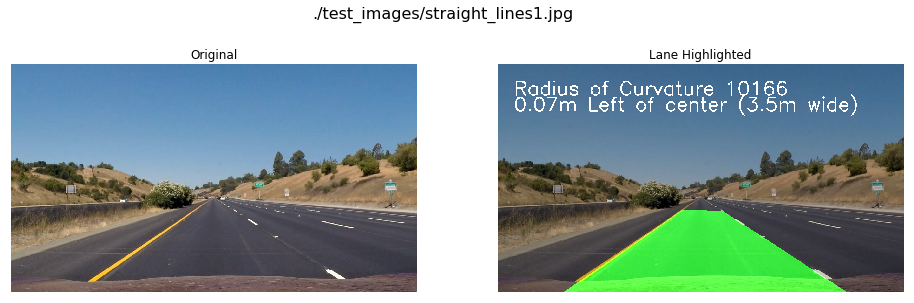

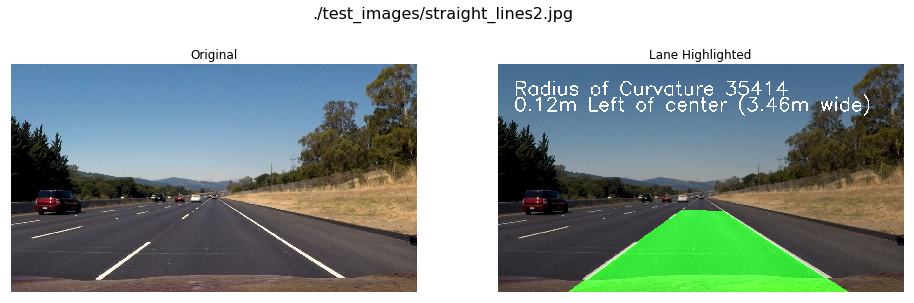

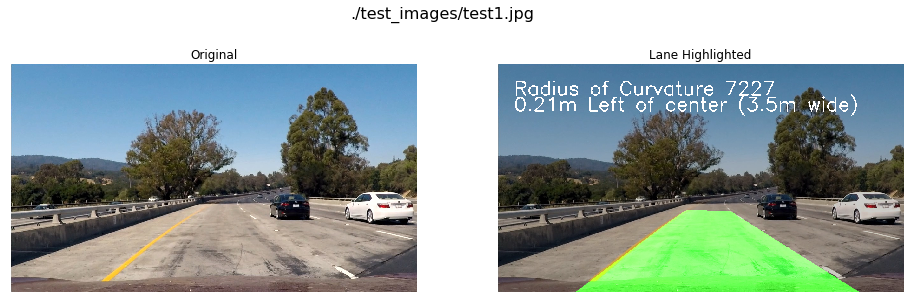

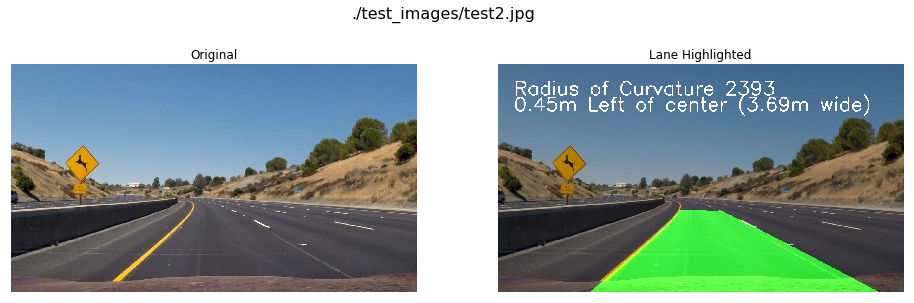

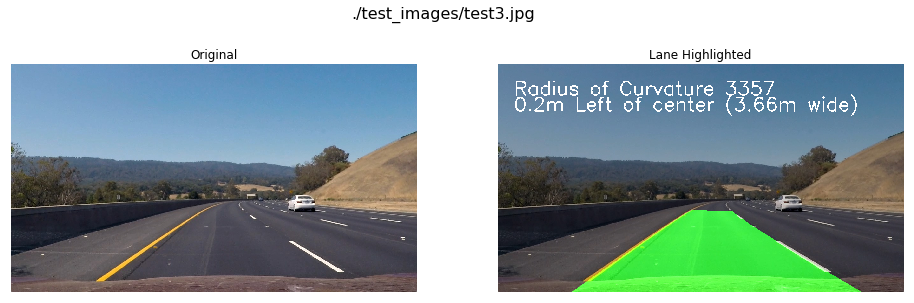

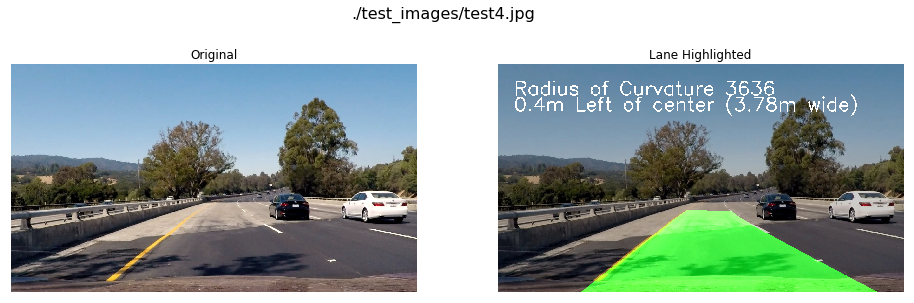

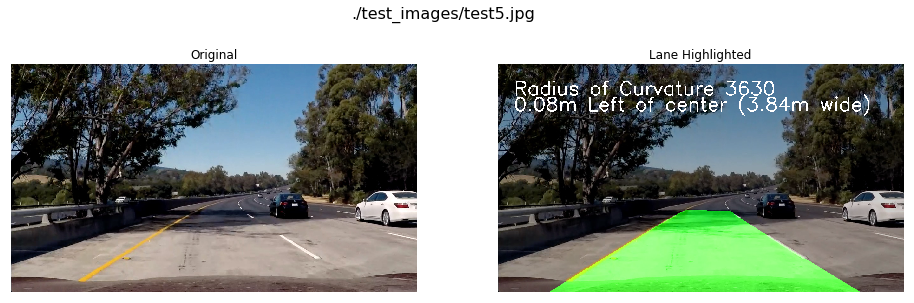

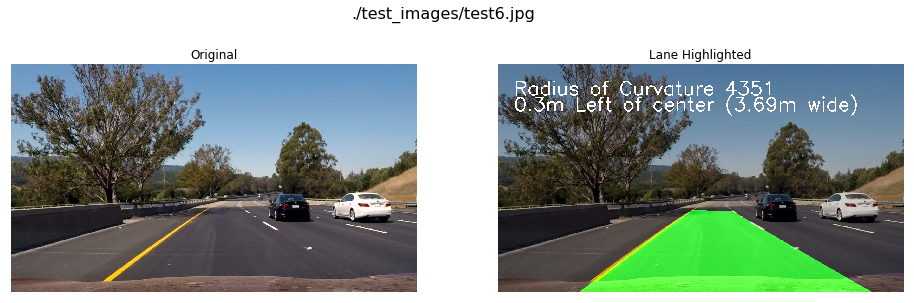

In [29]:
inDir = "test_images/"
outDir = "output_images/"

#image_file_list = os.listdir(inDir)

image_file_list = sorted(glob.glob('./test_images/*.jpg'))
nRows, nCols = len(image_file_list), 3


for i in range(len(image_file_list)):
    ## TODO: Consider an architecture which decouples image data from the underlying source
    ## of that data.  This will allow a pipeline like this to be more easily used
    ## in embedded systems which may not operate on a file system.  What is needed is a
    ## container for an image which insulates the rest of the system from the image's
    ## origin and history.
    fname = image_file_list[i]
    output_file = os.path.join(outDir, os.path.basename(fname))
    image = mpimg.imread(fname)
    highlightedLanes = image_pipeline(image, outFileName=output_file, distortionMatrix=mtx)
     
    images = [image, highlightedLanes]
    captions = ['Original', 'Lane Highlighted']
    display_images(images, captions, shape=(1, len(images)), figuresize=(5,16), figuretitle=fname) 

# Test on Videos

Note: if you get an import error when you run the next cell, try changing your kernel (select the Kernel menu above --> Change Kernel). Still have problems? Try relaunching Jupyter Notebook from the terminal prompt. Also, consult the forums for more troubleshooting tips.

If you get an error that looks like this:

NeedDownloadError: Need ffmpeg exe. 
You can download it by calling: 
imageio.plugins.ffmpeg.download()
Follow the instructions in the error message and check out this forum post for more troubleshooting tips across operating systems.

In [67]:
# Import everything needed to edit/save/watch video clips
from moviepy.editor import VideoFileClip
from IPython.display import HTML

In [68]:
def process_image(image):
    # NOTE: The output you return should be a color image (3 channel) for processing video below
    # TODO: put your pipeline here,
    highlightedLanes = image_pipeline(image, thickness=6)
    
    # you should return the final output (image where lines are drawn on lanes
    return highlightedLanes

# Test the Pipeline on a Video

In [69]:
#white_output = 'test_videos_output/solidWhiteRight.mp4'
input_video_file = 'project_video.mp4'
out_dir = 'output_videos'
output_video_file = os.path.join(outDir, input_video_file)
## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
clip1 = VideoFileClip(input_video_file).subclip(0,5)
#clip1 = VideoFileClip(input_video_file).subclip(0,3)
#clip1 = VideoFileClip(input_video_file)
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(output_video_file, audio=False)


[MoviePy] >>>> Building video output_images/project_video.mp4
[MoviePy] Writing video output_images/project_video.mp4



 99%|█████████▉| 125/126 [00:29<00:00,  3.97it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: output_images/project_video.mp4 

CPU times: user 16.3 s, sys: 3.68 s, total: 20 s
Wall time: 32.2 s


Play the video inline...

In [70]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(output_video_file))

# Test the Pipeline on a More Challenging Video

In [71]:
input_video_file = 'challenge_video.mp4'
out_dir = 'output_videos'
output_video_file = os.path.join(outDir, input_video_file)
## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
#clip1 = VideoFileClip(input_video_file).subclip(0,5)
clip1 = VideoFileClip(input_video_file).subclip(3,8)
#clip1 = VideoFileClip(input_video_file)
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(output_video_file, audio=False)


[MoviePy] >>>> Building video output_images/challenge_video.mp4
[MoviePy] Writing video output_images/challenge_video.mp4



100%|██████████| 150/150 [00:36<00:00,  3.93it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: output_images/challenge_video.mp4 

CPU times: user 18.8 s, sys: 4.64 s, total: 23.5 s
Wall time: 39 s


In [72]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(output_video_file))

# ...and on an even more challenging video

In [73]:
input_video_file = 'harder_challenge_video.mp4'
out_dir = 'output_videos'
output_video_file = os.path.join(outDir, input_video_file)
## To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
## To do so add .subclip(start_second,end_second) to the end of the line below
## Where start_second and end_second are integer values representing the start and end of the subclip
## You may also uncomment the following line for a subclip of the first 5 seconds
#clip1 = VideoFileClip(input_video_file).subclip(0,5)
clip1 = VideoFileClip(input_video_file).subclip(3,8)
#clip1 = VideoFileClip(input_video_file)
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(output_video_file, audio=False)


[MoviePy] >>>> Building video output_images/harder_challenge_video.mp4
[MoviePy] Writing video output_images/harder_challenge_video.mp4



 99%|█████████▉| 125/126 [00:31<00:00,  3.70it/s]


[MoviePy] Done.
[MoviePy] >>>> Video ready: output_images/harder_challenge_video.mp4 

CPU times: user 16.8 s, sys: 4.01 s, total: 20.8 s
Wall time: 35.9 s


In [74]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(output_video_file))

In [ ]:
"""
==================
Animated histogram
==================

Use a path patch to draw a bunch of rectangles for an animated histogram.
"""
%matplotlib inline
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import matplotlib.animation as animation
from IPython.display import HTML

# Fixing random state for reproducibility
np.random.seed(19680801)

# histogram our data with numpy
data = np.random.randn(1000)
n, bins = np.histogram(data, 100)

# get the corners of the rectangles for the histogram
left = np.array(bins[:-1])
right = np.array(bins[1:])
bottom = np.zeros(len(left))
top = bottom + n
nrects = len(left)

###############################################################################
# Here comes the tricky part -- we have to set up the vertex and path codes
# arrays using ``plt.Path.MOVETO``, ``plt.Path.LINETO`` and
# ``plt.Path.CLOSEPOLY`` for each rect.
#
# * We need 1 ``MOVETO`` per rectangle, which sets the initial point.
# * We need 3 ``LINETO``'s, which tell Matplotlib to draw lines from
#   vertex 1 to vertex 2, v2 to v3, and v3 to v4.
# * We then need one ``CLOSEPOLY`` which tells Matplotlib to draw a line from
#   the v4 to our initial vertex (the ``MOVETO`` vertex), in order to close the
#   polygon.
#
# .. note::
#
#   The vertex for ``CLOSEPOLY`` is ignored, but we still need a placeholder
#   in the ``verts`` array to keep the codes aligned with the vertices.
nverts = nrects * (1 + 3 + 1)
verts = np.zeros((nverts, 2))
codes = np.ones(nverts, int) * path.Path.LINETO
codes[0::5] = path.Path.MOVETO
codes[4::5] = path.Path.CLOSEPOLY
verts[0::5, 0] = left
verts[0::5, 1] = bottom
verts[1::5, 0] = left
verts[1::5, 1] = top
verts[2::5, 0] = right
verts[2::5, 1] = top
verts[3::5, 0] = right
verts[3::5, 1] = bottom

###############################################################################
# To animate the histogram, we need an ``animate`` function, which generates
# a random set of numbers and updates the locations of the vertices for the
# histogram (in this case, only the heights of each rectangle). ``patch`` will
# eventually be a ``Patch`` object.
patch = None


def animate(i):
    # simulate new data coming in
    data = np.random.randn(1000)
    n, bins = np.histogram(data, 100)
    top = bottom + n
    verts[1::5, 1] = top
    verts[2::5, 1] = top
    return [patch, ]

###############################################################################
# And now we build the `Path` and `Patch` instances for the histogram using
# our vertices and codes. We add the patch to the `Axes` instance, and setup
# the `FuncAnimation` with our animate function.
fig, ax = plt.subplots()
barpath = path.Path(verts, codes)
patch = patches.PathPatch(
    barpath, facecolor='green', edgecolor='yellow', alpha=0.5)
ax.add_patch(patch)

ax.set_xlim(left[0], right[-1])
ax.set_ylim(bottom.min(), top.max())

ani = animation.FuncAnimation(fig, animate, 100, repeat=False, blit=True)
plt.show()

In [ ]:
%%capture
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation
plt.rcParams["animation.html"] = "jshtml"
import numpy as np

t = np.linspace(0,2*np.pi)
x = np.sin(t)

fig, ax = plt.subplots()
h = ax.axis([0,2*np.pi,-1,1])
l, = ax.plot([],[])

def animate(i):
    l.set_data(t[:i], x[:i])

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(t))

In [ ]:
ani